In [15]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [16]:
# =============================================================================
# 0. 설정
# =============================================================================

PROJECT_ROOT = Path(r"C:\Code\ott-churn-prediction")

DATA_PATH = PROJECT_ROOT / "park.ingyeom" / "data" / "260513_derived_membership.csv"

TARGET = "is_repurchase"

N_SPLITS = 5
RANDOM_STATE = 42
THRESHOLD = 0.5

OUTPUT_DIR = PROJECT_ROOT / "park.ingyeom" / "reports" / "baseline_outputs_260513"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DROP_COLS = [
    # 식별자
    "USER_KEY",
    "USER_NUM",
    "membership_row_id",

    # 원본 범주형 또는 파생변수로 대체한 컬럼
    "product_code",
    "billing_method",
    "payment_device",
    "gender",

    # 날짜
    "reg_date",
    "end_date",

    # 기존 논의 기준 제거 대상
    "price",
    "max_screen",
    "max_screen_num",
    "MAX_SCREEN_NUM",
]

# 타깃 누수 의심 컬럼 자동 제거
# TARGET인 is_repurchase 자체는 y로 분리하므로 제외됨
LEAKAGE_KEYWORDS = [
    "repurchase",
    "next_payment",
    "next_reg",
    "next_end",
    "future",
    "label",
]

In [17]:
# =============================================================================
# 1. 유틸 함수
# =============================================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(X: pd.DataFrame, scale_numeric: bool) -> ColumnTransformer:
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()

    if scale_numeric:
        numeric_pipe = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
    else:
        numeric_pipe = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]
        )

    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return preprocessor


def get_metrics(y_true, prob, threshold=0.5) -> dict:
    pred = (prob >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "log_loss": log_loss(y_true, prob, labels=[0, 1]),
        "brier": brier_score_loss(y_true, prob),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }


In [18]:
# =============================================================================
# 2. 데이터 로드
# =============================================================================

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"타깃 컬럼이 없습니다: {TARGET}")

df = df.copy()

# 타깃 결측 제거
df = df[df[TARGET].notna()].reset_index(drop=True)

# 타깃은 반드시 0/1 정수로 고정
df[TARGET] = df[TARGET].astype(int)

# 명시적 drop
drop_cols_existing = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=drop_cols_existing)

# 타깃 누수 의심 컬럼 제거
leakage_cols = []
for c in df.columns:
    if c == TARGET:
        continue

    c_lower = c.lower()
    for keyword in LEAKAGE_KEYWORDS:
        if keyword in c_lower:
            leakage_cols.append(c)
            break

leakage_cols = sorted(set(leakage_cols))

if leakage_cols:
    df = df.drop(columns=leakage_cols)

# X, y 분리
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 완전 상수 컬럼 제거
constant_cols = [
    c for c in X.columns
    if X[c].nunique(dropna=False) <= 1
]

if constant_cols:
    X = X.drop(columns=constant_cols)

# 사용 컬럼 기록
pd.DataFrame({
    "used_columns": X.columns
}).to_csv(
    OUTPUT_DIR / "baseline_used_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({
    "dropped_explicit_cols": drop_cols_existing
}).to_csv(
    OUTPUT_DIR / "baseline_dropped_explicit_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({
    "dropped_leakage_suspect_cols": leakage_cols
}).to_csv(
    OUTPUT_DIR / "baseline_dropped_leakage_suspect_columns.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame({
    "dropped_constant_cols": constant_cols
}).to_csv(
    OUTPUT_DIR / "baseline_dropped_constant_columns.csv",
    index=False,
    encoding="utf-8-sig",
)


print("=" * 80)
print("데이터 확인")
print("=" * 80)
print(f"DATA_PATH          : {DATA_PATH}")
print(f"df shape after drop: {df.shape}")
print(f"X shape            : {X.shape}")
print(f"y distribution     : {dict(y.value_counts().sort_index())}")
print(f"explicit drop cols : {drop_cols_existing}")
print(f"leakage drop cols  : {leakage_cols}")
print(f"constant drop cols : {constant_cols}")
print()

데이터 확인
DATA_PATH          : C:\Code\ott-churn-prediction\park.ingyeom\data\260513_derived_membership.csv
df shape after drop: (23343, 82)
X shape            : (23343, 81)
y distribution     : {0: 6641, 1: 16702}
explicit drop cols : ['USER_KEY', 'product_code', 'billing_method', 'payment_device', 'gender', 'reg_date', 'end_date', 'price', 'max_screen']
leakage drop cols  : []
constant drop cols : []



In [19]:
# =============================================================================
# 3. 모델 정의
# =============================================================================

neg_count = int((y == 0).sum())
pos_count = int((y == 1).sum())

scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

models = {
    "LogisticRegression": {
        "scale_numeric": True,
        "model": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    },

    "RandomForest": {
        "scale_numeric": False,
        "model": RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },

    "GradientBoosting": {
        "scale_numeric": False,
        "model": GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=20,
            subsample=0.8,
            random_state=RANDOM_STATE,
        ),
    },

    "XGBoost": {
        "scale_numeric": False,
        "model": XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_weight,
        ),
    },

    "LightGBM": {
        "scale_numeric": False,
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            n_jobs=-1,
            verbose=-1,
            random_state=RANDOM_STATE,
        ),
    },

    "CatBoost": {
        "scale_numeric": False,
        "model": CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=5,
            loss_function="Logloss",
            eval_metric="AUC",
            auto_class_weights="Balanced",
            verbose=0,
            random_state=RANDOM_STATE,
        ),
    },
}

In [20]:
# =============================================================================
# 4. 5-Fold CV
# =============================================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print("=" * 80)
print("CV Setting")
print("=" * 80)
print(f"CV method   : StratifiedKFold")
print(f"n_splits    : {N_SPLITS}")
print(f"shuffle     : True")
print(f"random_state: {RANDOM_STATE}")
print()

fold_rows = []
oof_pred = pd.DataFrame({
    "row_id": np.arange(len(y)),
    "y_true": y.values,
})

for model_name in models.keys():
    oof_pred[f"prob_{model_name}"] = np.nan


for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_tr = X.iloc[tr_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[tr_idx].copy()
    y_val = y.iloc[val_idx].copy()

    print("=" * 80)
    print(f"Fold {fold}")
    print("=" * 80)
    print(f"train y distribution: {dict(y_tr.value_counts().sort_index())}")
    print(f"valid y distribution: {dict(y_val.value_counts().sort_index())}")
    print()

    for model_name, spec in models.items():
        preprocessor = build_preprocessor(
            X=X_tr,
            scale_numeric=spec["scale_numeric"],
        )

        pipe = Pipeline(
            steps=[
                ("preprocess", preprocessor),
                ("model", clone(spec["model"])),
            ]
        )

        pipe.fit(X_tr, y_tr)

        train_prob = pipe.predict_proba(X_tr)[:, 1]
        test_prob = pipe.predict_proba(X_val)[:, 1]

        train_metrics = get_metrics(y_tr, train_prob, threshold=THRESHOLD)
        test_metrics = get_metrics(y_val, test_prob, threshold=THRESHOLD)

        oof_pred.loc[val_idx, f"prob_{model_name}"] = test_prob

        row = {
            "model": model_name,
            "fold": fold,
            "n_train": len(tr_idx),
            "n_valid": len(val_idx),
            "valid_positive_rate": float(y_val.mean()),
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"test_{k}": v for k, v in test_metrics.items()},
            "roc_auc_gap": train_metrics["roc_auc"] - test_metrics["roc_auc"],
            "pr_auc_gap": train_metrics["pr_auc"] - test_metrics["pr_auc"],
            "f1_gap": train_metrics["f1"] - test_metrics["f1"],
        }

        fold_rows.append(row)

        print(
            f"{model_name:<20} "
            f"Train ROC-AUC={train_metrics['roc_auc']:.4f} | "
            f"Test ROC-AUC={test_metrics['roc_auc']:.4f} | "
            f"Gap={train_metrics['roc_auc'] - test_metrics['roc_auc']:.4f} | "
            f"Test PR-AUC={test_metrics['pr_auc']:.4f} | "
            f"Test F1={test_metrics['f1']:.4f} | "
            f"Test Recall={test_metrics['recall']:.4f} | "
            f"Test Precision={test_metrics['precision']:.4f}"
        )

    print()

CV Setting
CV method   : StratifiedKFold
n_splits    : 5
shuffle     : True
random_state: 42

Fold 1
train y distribution: {0: 5313, 1: 13361}
valid y distribution: {0: 1328, 1: 3341}

LogisticRegression   Train ROC-AUC=0.8552 | Test ROC-AUC=0.8495 | Gap=0.0057 | Test PR-AUC=0.9348 | Test F1=0.8149 | Test Recall=0.7489 | Test Precision=0.8936
RandomForest         Train ROC-AUC=0.9750 | Test ROC-AUC=0.8622 | Gap=0.1128 | Test PR-AUC=0.9387 | Test F1=0.8577 | Test Recall=0.8453 | Test Precision=0.8705
GradientBoosting     Train ROC-AUC=0.8875 | Test ROC-AUC=0.8760 | Gap=0.0115 | Test PR-AUC=0.9487 | Test F1=0.8756 | Test Recall=0.9168 | Test Precision=0.8380
XGBoost              Train ROC-AUC=0.9139 | Test ROC-AUC=0.8796 | Gap=0.0342 | Test PR-AUC=0.9495 | Test F1=0.8403 | Test Recall=0.7749 | Test Precision=0.9178
LightGBM             Train ROC-AUC=0.9573 | Test ROC-AUC=0.8800 | Gap=0.0773 | Test PR-AUC=0.9489 | Test F1=0.8516 | Test Recall=0.7989 | Test Precision=0.9119
CatBoost       

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Code\\ott-churn-prediction\\park.ingyeom\\reports\\baseline_outputs_260513\\baseline_train_test_auc_bar.png'

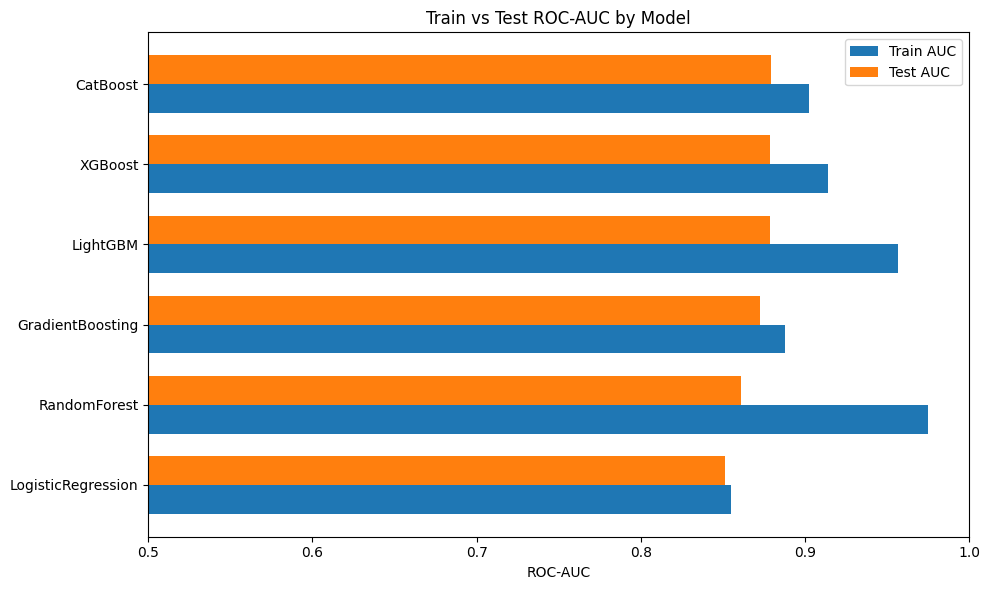

In [21]:
# =============================================================================
# 5. 결과 저장
# =============================================================================

fold_result = pd.DataFrame(fold_rows)

summary = (
    fold_result
    .groupby("model")
    .agg(
        train_roc_auc_mean=("train_roc_auc", "mean"),
        test_roc_auc_mean=("test_roc_auc", "mean"),
        test_roc_auc_std=("test_roc_auc", "std"),
        roc_auc_gap_mean=("roc_auc_gap", "mean"),
        roc_auc_gap_max=("roc_auc_gap", "max"),
        train_pr_auc_mean=("train_pr_auc", "mean"),
        test_pr_auc_mean=("test_pr_auc", "mean"),
        test_pr_auc_std=("test_pr_auc", "std"),
        pr_auc_gap_mean=("pr_auc_gap", "mean"),
        train_f1_mean=("train_f1", "mean"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        f1_gap_mean=("f1_gap", "mean"),
        test_recall_mean=("test_recall", "mean"),
        test_precision_mean=("test_precision", "mean"),
        test_log_loss_mean=("test_log_loss", "mean"),
        test_brier_mean=("test_brier", "mean"),
    )
    .reset_index()
    .sort_values("test_roc_auc_mean", ascending=False)
)

def judge_overfitting(gap: float) -> str:
    if gap >= 0.08:
        return "high_overfit_risk"
    if gap >= 0.04:
        return "moderate_overfit_risk"
    if gap >= 0.02:
        return "mild_overfit_risk"
    return "low_overfit_risk"


summary["overfit_assessment"] = summary["roc_auc_gap_mean"].apply(judge_overfitting)

auc_plot_data = summary.sort_values("test_roc_auc_mean", ascending=True)
y_pos = np.arange(len(auc_plot_data))

plt.figure(figsize=(10, 6))
plt.barh(y_pos - 0.18, auc_plot_data["train_roc_auc_mean"], height=0.36, label="Train AUC")
plt.barh(y_pos + 0.18, auc_plot_data["test_roc_auc_mean"], height=0.36, label="Test AUC")
plt.yticks(y_pos, auc_plot_data["model"])
plt.xlabel("ROC-AUC")
plt.title("Train vs Test ROC-AUC by Model")
plt.xlim(0.5, 1.0)
plt.legend()
plt.tight_layout()
auc_bar_path = OUTPUT_DIR / "baseline_train_test_auc_bar.png"
plt.savefig(auc_bar_path, dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
for model_name, model_fold_result in fold_result.groupby("model"):
    plt.plot(
        model_fold_result["fold"],
        model_fold_result["test_roc_auc"],
        marker="o",
        label=model_name,
    )
plt.xlabel("Fold")
plt.ylabel("Test ROC-AUC")
plt.title("Test ROC-AUC by Fold")
plt.xticks(range(1, N_SPLITS + 1))
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
auc_fold_path = OUTPUT_DIR / "baseline_fold_test_auc_line.png"
plt.savefig(auc_fold_path, dpi=150)
plt.show()

fold_result.to_csv(
    OUTPUT_DIR / "baseline_cv_fold_results.csv",
    index=False,
    encoding="utf-8-sig",
)

summary.to_csv(
    OUTPUT_DIR / "baseline_cv_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

oof_pred.to_csv(
    OUTPUT_DIR / "baseline_oof_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


print("=" * 80)
print("CV Summary")
print("=" * 80)

display_cols = [
    "model",
    "train_roc_auc_mean",
    "test_roc_auc_mean",
    "test_roc_auc_std",
    "roc_auc_gap_mean",
    "roc_auc_gap_max",
    "train_pr_auc_mean",
    "test_pr_auc_mean",
    "pr_auc_gap_mean",
    "train_f1_mean",
    "test_f1_mean",
    "f1_gap_mean",
    "test_recall_mean",
    "test_precision_mean",
    "test_log_loss_mean",
    "overfit_assessment",
]

print(summary[display_cols].to_string(index=False))

print()
print("=" * 80)
print("Overfitting Judgment")
print("=" * 80)
print("판단 기준: train ROC-AUC 평균 - test ROC-AUC 평균")
print("0.02 미만: 낮음 | 0.02 이상: 약함 | 0.04 이상: 중간 | 0.08 이상: 높음")
print(summary[["model", "train_roc_auc_mean", "test_roc_auc_mean", "roc_auc_gap_mean", "overfit_assessment"]].to_string(index=False))

print()
print("=" * 80)
print("Saved files")
print("=" * 80)
print(OUTPUT_DIR / "baseline_cv_fold_results.csv")
print(OUTPUT_DIR / "baseline_cv_summary.csv")
print(OUTPUT_DIR / "baseline_oof_predictions.csv")
print(auc_bar_path)
print(auc_fold_path)
print(OUTPUT_DIR / "baseline_used_columns.csv")
print(OUTPUT_DIR / "baseline_dropped_explicit_columns.csv")
print(OUTPUT_DIR / "baseline_dropped_leakage_suspect_columns.csv")
print(OUTPUT_DIR / "baseline_dropped_constant_columns.csv")